In [10]:
# for interactive plots:
# %matplotlib widget

# for static plots:
%matplotlib inline

In [23]:
import matplotlib.pyplot as plt

# Optics calculation and matching

For more info, see [Twiss](https://xsuite.readthedocs.io/en/latest/twiss.html) and [Match](https://xsuite.readthedocs.io/en/latest/match.html) sections in the User's Guide.

In [24]:
import xtrack as xt

### Load model

In [25]:
env = xt.load('./pimm.json')

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

In [26]:
env

Environment(2 lines: {cell_a, ring}, 86 elements, 12 vars, 0 particles)

In [27]:
ring = env['ring']

### Survey and plot geometry

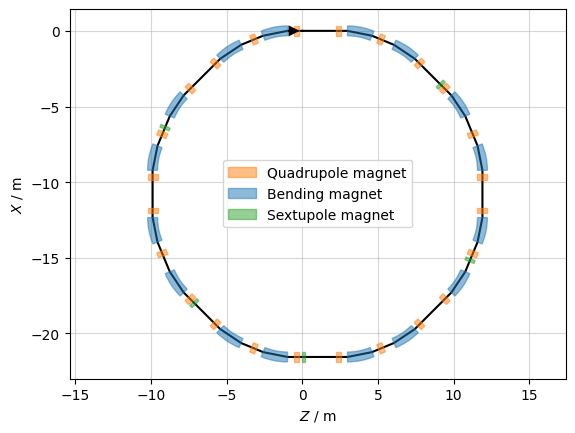

In [28]:
sv = ring.survey()
sv.plot()

### Inspect beamline table

Xsuite tables are used as output for many Xsuite functionalities (e.g. Twiss and Survey). They have many handy row/cols selection capabilities (see ["Working with tables" in the User's guide](https://xsuite.readthedocs.io/en/latest/tables.html)).

In [29]:
tt = ring.get_table()
tt.cols['element_type s_start s_center s_end']

LineTable: 110 rows, 5 cols
name          element_type       s_start      s_center         s_end
||drift_13::0 Drift                    0           0.5             1
mid.lss.0     Marker                   1             1             1
||drift_13::1 Drift                    1           1.5             2
||drift_1::0  Drift                    2       2.10625        2.2125
qfal.0        Quadrupole          2.2125        2.3875        2.5625
||drift_2::0  Drift               2.5625       2.77234       2.98218
mb.0          RBend              2.98218        3.8125       4.64282
||drift_3::0  Drift              4.64282       4.88016        5.1175
qd.0          Quadrupole          5.1175        5.2925        5.4675
||drift_4::0  Drift               5.4675       5.84234       6.21718
...
||drift_4::3 Drift              65.0228       65.3977       65.7725
qd.7         Quadrupole         65.7725       65.9475       66.1225
||drift_3::3 Drift              66.1225       66.3598       66.5972
mb.15

In [30]:
# Inspect all quadrupoles
tt_quad = tt.rows.match(element_type='Quadrupole')
tt_quad.cols['s_start s_center s_end']

LineTable: 24 rows, 4 cols
name         s_start      s_center         s_end
qfal.0        2.2125        2.3875        2.5625
qd.0          5.1175        5.2925        5.4675
qfar.0        8.1525        8.3275        8.5025
qfb.0        10.5025       10.6775       10.8525
qd.1         14.0875       14.2625       14.4375
qfb.1        17.0225       17.1975       17.3725
qfb.2        19.2475       19.4225       19.5975
qd.2         22.1825       22.3575       22.5325
qfb.3        25.7675       25.9425       26.1175
qfar.1       28.1175       28.2925       28.4675
qd.3         31.1525       31.3275       31.5025
qfal.1       34.0575       34.2325       34.4075
qfal.2       36.8325       37.0075       37.1825
qd.4         39.7375       39.9125       40.0875
qfar.2       42.7725       42.9475       43.1225
qfb.4        45.1225       45.2975       45.4725
qd.5         48.7075       48.8825       49.0575
qfb.5        51.6425       51.8175       51.9925
qfb.6        53.8675       54.0425       5

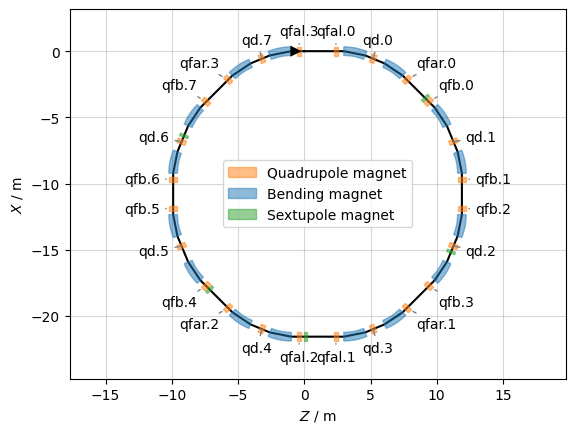

In [31]:
# Tag all quadrupoles in survey plot
sv = ring.survey()
sv.plot(labels=tt_quad.name);

### Set reference particle

In [32]:
ring.set_particle_ref('proton', kinetic_energy0=100e6)

### Inspect quadrupole circuits

In [33]:
env.info('kqfa')

Info for vars['kqfa']

value: 0.0

Not controlled by other entities.

controlled_targets:
   element_refs['qfar.3'].k1
   element_refs['qfar.2'].k1
   element_refs['qfar.1'].k1
   element_refs['qfar.0'].k1
   element_refs['qfal.3'].k1
   element_refs['qfal.2'].k1
   element_refs['qfal.1'].k1
   element_refs['qfal.0'].k1
   element_refs['qfar'].k1
   element_refs['qfal'].k1
   element_refs['qfa'].k1



In [34]:
env.info('kqfb')

Info for vars['kqfb']

value: 0.0

Not controlled by other entities.

controlled_targets:
   element_refs['qfb.7'].k1
   element_refs['qfb.6'].k1
   element_refs['qfb.5'].k1
   element_refs['qfb.4'].k1
   element_refs['qfb.3'].k1
   element_refs['qfb.2'].k1
   element_refs['qfb.1'].k1
   element_refs['qfb.0'].k1
   element_refs['qfb'].k1



### Set some initial strengths to get a first twiss

In [35]:
env['kqfa'] =  0.01
env['kqfb'] =  0.01
env['kqd']  = -0.02

In [36]:
# Compute twiss parameters
tw = ring.twiss4d(chrom=False)

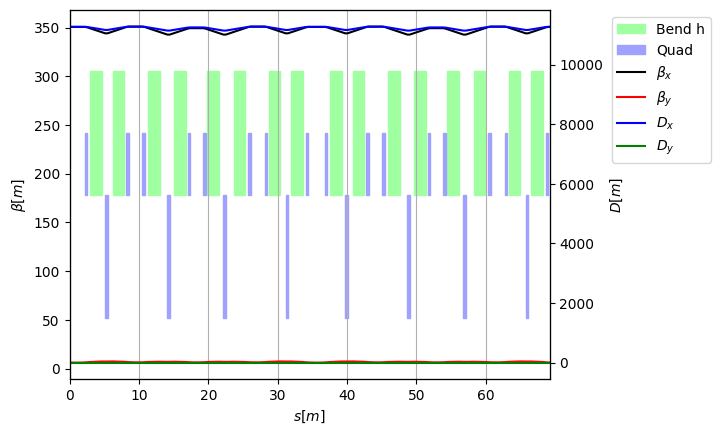

In [37]:
# Plot twiss parameters
tw.plot()

### Match the tunes

In [38]:
opt_tune = ring.match(
    solve=False, # <- prepare the match without running it
    chrom=False,
    method='4d',
    vary=[
        xt.Vary('kqfa', limits=(0, 10),  step=1e-3),
        xt.Vary('kqfb', limits=(0, 10),  step=1e-3),
        xt.Vary('kqd', limits=(-10, 0), step=1e-3),
    ],
    targets=[
        xt.TargetSet(qx=1.64, qy=1.72, tol=1e-6),
    ]
)

In [39]:
opt_tune.target_status()

Target status:               alty = 1.6107e+01              
id state tag tol_met       residue   current_val    target_val description                         
0  ON    qx    False      -1.60864     0.0313631          1.64 'qx', val=1.64, tol=1e-06, weight=10
1  ON    qy    False    -0.0807693       1.63923          1.72 'qy', val=1.72, tol=1e-06, weight=10


In [40]:
opt_tune.run_jacobian(30)

                                             
Optimize - start penalty: 16.11                             
Matching: model call n. 32 penalty = 1.3669e-08              
Optimize - end penalty:  1.36687e-08                            


In [41]:
opt_tune.target_status()

Target status:               nalty = 1.3669e-08              
id state tag tol_met       residue   current_val    target_val description                         
0  ON    qx     True  -1.36671e-09          1.64          1.64 'qx', val=1.64, tol=1e-06, weight=10
1  ON    qy     True   -2.1114e-11          1.72          1.72 'qy', val=1.72, tol=1e-06, weight=10


In [42]:
opt_tune.vary_status()

Vary status:                 
id state tag met name lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqfa           0      0.435867          10          0.01         0.001             1
1  ON        OK  kqfb           0      0.440097          10          0.01         0.001             1
2  ON        OK  kqd          -10     -0.585124           0         -0.02         0.001             1


### Inspect the optics

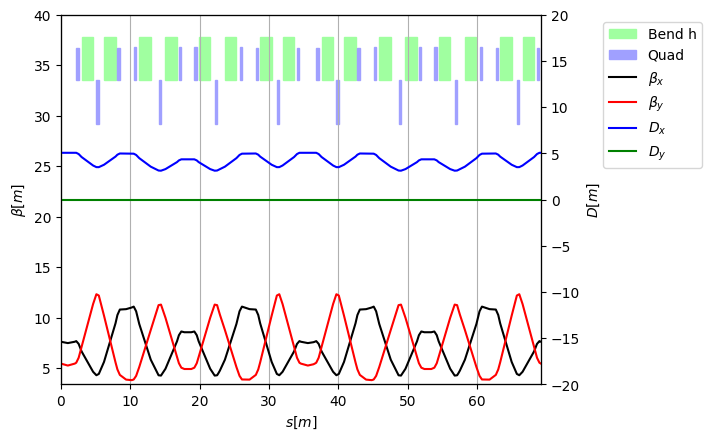

In [43]:
# Twiss and plot again
tw = ring.twiss4d()
pl = tw.plot()
pl.ylim(left_hi=40, right_lo=-20, right_hi=20,
        lattice_hi=1.5, lattice_lo=-7)

### Add constraint on dispersion at the center of the long straight sections

In [44]:
opt_disp = opt_tune.clone(
    add_targets=[
        xt.TargetSet(dx=0, at='mid.lss.0', tol=1e-3),
        xt.TargetSet(dx=0, at='mid.lss.1', tol=1e-3),
    ])

In [45]:
opt_disp.target_status()

Target status:               alty = 7.1697e+01              
id state tag          tol_met       residue   current_val    target_val description                                 
0  ON    qx              True  -1.36671e-09          1.64          1.64 'qx', val=1.64, tol=1e-06, weight=10        
1  ON    qy              True   -2.1114e-11          1.72          1.72 'qy', val=1.72, tol=1e-06, weight=10        
2  ON    mid.lss.0_dx   False       5.06976       5.06976             0 ('dx', 'mid.lss.0'), val=0, tol=0.001, w ...
3  ON    mid.lss.1_dx   False       5.06976       5.06976             0 ('dx', 'mid.lss.1'), val=0, tol=0.001, w ...


In [46]:
opt_disp.run_simplex(100)

                                             
Optimize - start penalty: 71.7                              
Matching: model call n. 185 penalty = 6.5467e-05              
Optimize - end penalty:  6.54674e-05                            


### Inspect the optics

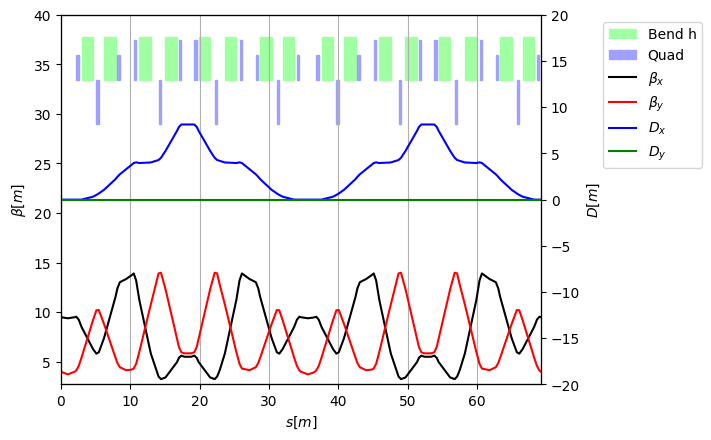

In [47]:
tw = ring.twiss4d()
pl = tw.plot()
pl.ylim(left_hi=40, right_lo=-20, right_hi=20,
        lattice_hi=1.5, lattice_lo=-7)